In [5]:
import sys
import os
import pandas as pd
sys.path.append(os.path.abspath('../'))
import pandas as pd
import os
from src.model_training import evaluate_model, perform_cross_validation
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [6]:
X_train = pd.read_csv('../data/processed/X_train_final.csv')
y_train = pd.read_csv('../data/processed/y_train_final.csv').values.ravel()
X_test = pd.read_csv('../data/processed/X_test_final.csv')
y_test = pd.read_csv('../data/processed/y_test_final.csv').values.ravel()

Training Baseline Model...

--- Logistic Regression (Baseline) Evaluation ---
              precision    recall  f1-score   support

           0       0.97      0.93      0.95     27393
           1       0.52      0.70      0.60      2830

    accuracy                           0.91     30223
   macro avg       0.75      0.82      0.77     30223
weighted avg       0.93      0.91      0.92     30223

AUC-ROC: 0.8334
AUC-PR (Precision-Recall): 0.6414
F1-Score: 0.5986


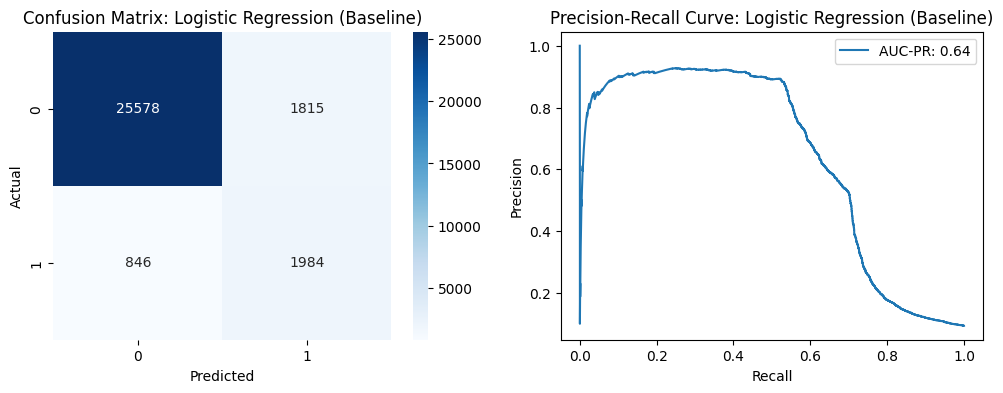

In [7]:
print("Training Baseline Model...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_results = evaluate_model(lr_model, X_test, y_test, "Logistic Regression (Baseline)")

Training Ensemble Model...

--- Random Forest (Ensemble) Evaluation ---
              precision    recall  f1-score   support

           0       0.97      0.95      0.96     27393
           1       0.58      0.68      0.62      2830

    accuracy                           0.92     30223
   macro avg       0.77      0.81      0.79     30223
weighted avg       0.93      0.92      0.93     30223

AUC-ROC: 0.8342
AUC-PR (Precision-Recall): 0.7051
F1-Score: 0.6215


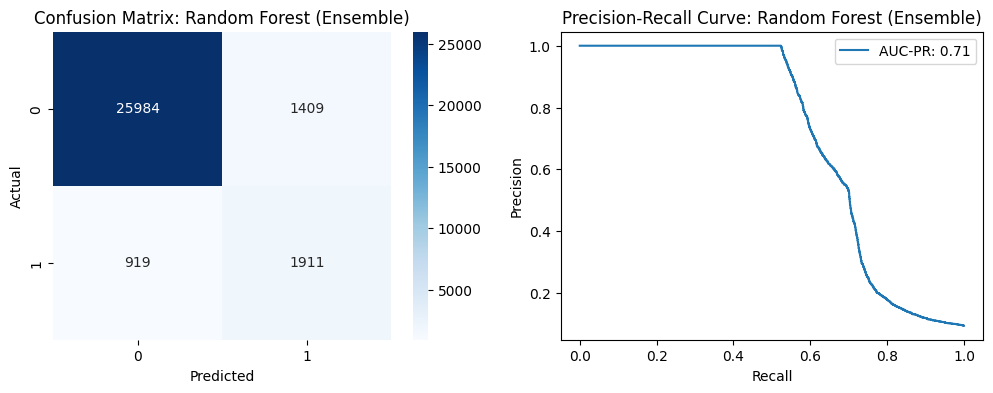

In [8]:
print("Training Ensemble Model...")
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    n_jobs=-1, 
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_results = evaluate_model(rf_model, X_test, y_test, "Random Forest (Ensemble)")


In [9]:
cv_results = perform_cross_validation(rf_model, X_train, y_train)


--- 5-Fold Cross Validation ---
Mean AUC-PR: 0.9549 (+/- 0.0007)
Mean F1-Score: 0.8717


In [10]:
comparison = pd.DataFrame({
    'Metric': ['AUC-ROC', 'AUC-PR', 'F1-Score'],
    'Logistic Regression': [lr_results['AUC-ROC'], lr_results['AUC-PR'], lr_results['F1']],
    'Random Forest': [rf_results['AUC-ROC'], rf_results['AUC-PR'], rf_results['F1']]
})

print("\n--- Final Model Comparison ---")
print(comparison)


--- Final Model Comparison ---
     Metric  Logistic Regression  Random Forest
0   AUC-ROC             0.833387       0.834179
1    AUC-PR             0.641355       0.705133
2  F1-Score             0.598582       0.621463
